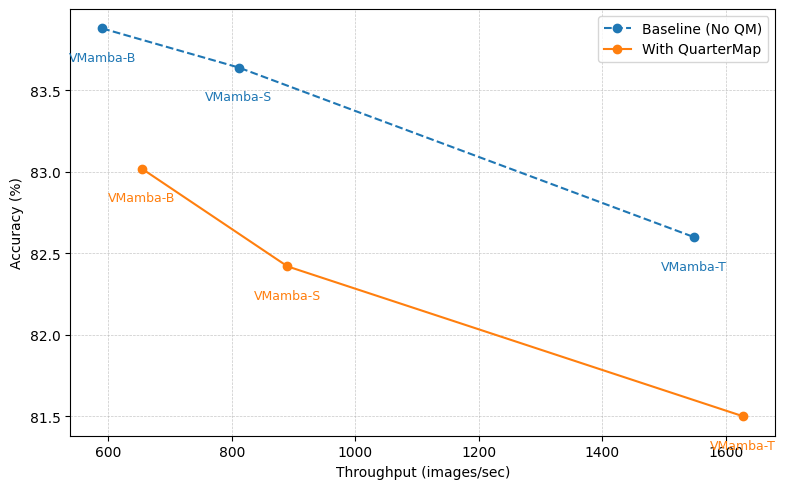

In [20]:
import matplotlib.pyplot as plt

# Data for before/after throughput vs accuracy figure
models = ['VMamba-B', 'VMamba-S', 'VMamba-T']
throughput_before = [590, 811, 1548]  # Baseline throughput
accuracy_before = [83.88, 83.64, 82.6]  # Baseline accuracy
throughput = [654, 890, 1628]  # With QuarterMap throughput
accuracy = [83.02, 82.42, 81.5]  # With QuarterMap accuracy

# Create a line chart for before/after comparison with model type annotations
fig, ax = plt.subplots(figsize=(8, 5))

# Plot before (baseline) and after (QuarterMap)
ax.plot(throughput_before, accuracy_before, marker='o', linestyle='--', color='tab:blue', label='Baseline (No QM)')
ax.plot(throughput, accuracy, marker='o', linestyle='-', color='tab:orange', label='With QuarterMap')

# Add labels and title
ax.set_xlabel('Throughput (images/sec)')
ax.set_ylabel('Accuracy (%)')
ax.legend()

# Annotate points with model types
for i, model in enumerate(models):
    ax.text(throughput_before[i], accuracy_before[i] - 0.2, model, fontsize=9, ha='center', color='tab:blue')
    ax.text(throughput[i], accuracy[i] - 0.2, model, fontsize=9, ha='center', color='tab:orange')

# Add grid and adjust layout
plt.grid(visible=True, which="both", linestyle='--', linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.savefig('figure_1_throughput_vs_accuracy_1.png')

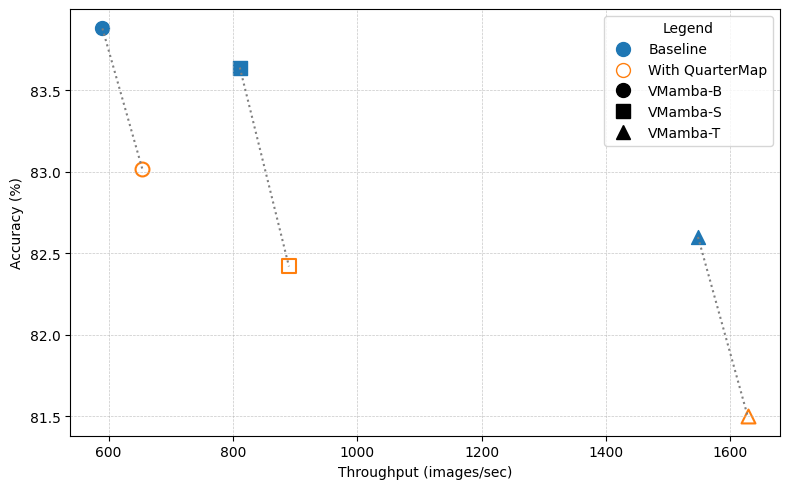

In [18]:
# Streamlined legend for better clarity
fig, ax = plt.subplots(figsize=(8, 5))

# Define shapes for different models
shapes = ['o', 's', '^']  # Circle for B, Square for S, Triangle for T

# Plot before (baseline) with filled markers and different shapes
for i, shape in enumerate(shapes):
    ax.scatter(throughput_before[i], accuracy_before[i], color='tab:blue', s=100, marker=shape)

# Plot after (QuarterMap) with hollow markers and different shapes
for i, shape in enumerate(shapes):
    ax.scatter(throughput[i], accuracy[i], edgecolor='tab:orange', facecolor='white', s=100,
               marker=shape, linewidth=1.5)

# Add labels and title
ax.set_xlabel('Throughput (images/sec)', fontsize=10)
ax.set_ylabel('Accuracy (%)', fontsize=10)

# Custom legend to streamline solid and hollow differences
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='tab:blue', label='Baseline', markersize=10, linestyle='None'),
    plt.Line2D([0], [0], marker='o', color='tab:orange', markerfacecolor='white', label='With QuarterMap', markersize=10, linestyle='None'),
    plt.Line2D([0], [0], marker='o', color='black', label='VMamba-B', markersize=10, linestyle='None'),
    plt.Line2D([0], [0], marker='s', color='black', label='VMamba-S', markersize=10, linestyle='None'),
    plt.Line2D([0], [0], marker='^', color='black', label='VMamba-T', markersize=10, linestyle='None')
]
ax.legend(handles=legend_elements, loc='best', title='Legend', title_fontsize=10)


# Add connecting lines between before and after for each model
for i in range(len(models)):
    ax.plot([throughput_before[i], throughput[i]], [accuracy_before[i], accuracy[i]], linestyle=':', color='gray')

# Add grid and adjust layout
plt.grid(visible=True, which="both", linestyle='--', linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.savefig('figure_1_throughput_vs_accuracy_2.png', dpi=500)


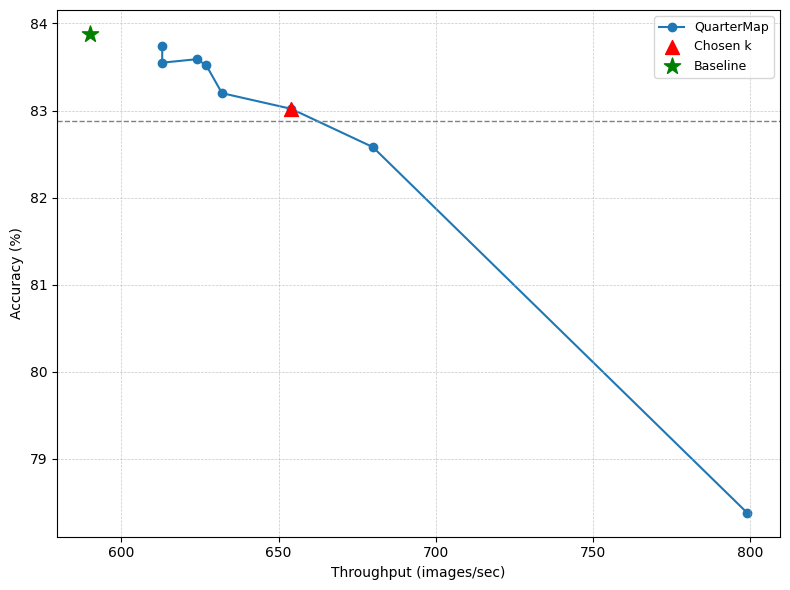

In [25]:
import matplotlib.pyplot as plt

# Raw data
baseline_throughput = 590
baseline_accuracy = 83.88

freqs = [1, 2, 3, 4, 5, 6, 7, 8]
throughput_no_first = [799, 680, 654, 632, 627, 624, 613, 613]
accuracy_no_first = [78.38, 82.58, 83.02, 83.20, 83.52, 83.59, 83.55, 83.74]

# Highlight the chosen k value
chosen_idx = freqs.index(3)

# Create the plot

# Updated plot with a star for the baseline and a triangle for the chosen point (k = 3)
fig, ax = plt.subplots(figsize=(8, 6))

# Plot the blue line and markers for the "No First Layer" strategy
ax.plot(throughput_no_first, accuracy_no_first, marker='o', linestyle='-', color='tab:blue', label='QuarterMap', zorder=1)

# Highlight the chosen k value (k = 3) with a red triangle
ax.scatter(throughput_no_first[chosen_idx], accuracy_no_first[chosen_idx], color='red', s=100, marker='^', label='Chosen k', zorder=2)

# Plot the baseline point as a green star
ax.scatter(baseline_throughput, baseline_accuracy, color='green', s=150, marker='*', label='Baseline', zorder=2)

baseline_drop_1 = baseline_accuracy - 1  # 1% accuracy drop
ax.axhline(y=baseline_drop_1, color='gray', linestyle='--', linewidth=1)

# Add labels and title
ax.set_xlabel('Throughput (images/sec)', fontsize=10)
ax.set_ylabel('Accuracy (%)', fontsize=10)

# Add grid and legend
ax.legend(fontsize=9)  # Legend to clarify markers
ax.grid(visible=True, which="both", linestyle='--', linewidth=0.5, alpha=0.7)

# Adjust layout and show
plt.tight_layout()
plt.savefig('figure_pareto_optimal_tradeoff.png', dpi=500)
